In [38]:
import numpy as np
import pandas as pd

In [39]:
columns = [
    'Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
    'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins',
    'Color_intensity', 'Hue', 'OD280_OD315_of_diluted_wines', 'Proline'
]

df = pd.read_csv('wine.data', header=None, names=columns)
display(df.head())

,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic_acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total_phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280_OD315_of_diluted_wines  178 non-null    float64
 13  Proli

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

In [42]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

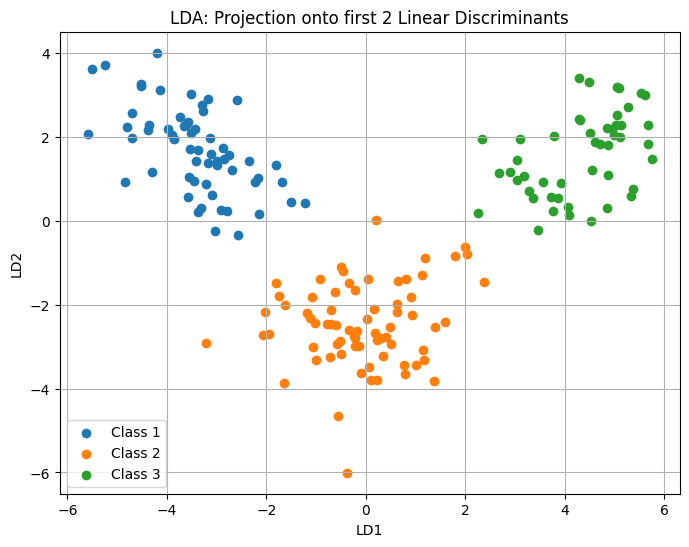

LDA Projection saved to lda_projection.csv


In [43]:
lda2 = LinearDiscriminantAnalysis(n_components=2)
X_lda2 = lda2.fit_transform(X_scaled, y)

lda_df = pd.DataFrame(X_lda2, columns=['LD1', 'LD2'])
lda_df['Class'] = y.values
lda_df.index.name = 'SampleId'
lda_df.to_csv('lda_projection.csv')

plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X_lda2[y == label, 0], X_lda2[y == label, 1], label=f'Class {label}')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA: Projection onto first 2 Linear Discriminants')
plt.legend()
plt.grid(True)
plt.show()

print("LDA Projection saved to lda_projection.csv")

In [44]:
def evaluate_model(X_tr, X_te, y_tr, y_te, description):
    clf = LogisticRegression(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')
    return {'Model': description, 'Accuracy': acc, 'F1-Score': f1}

results = []

results.append(evaluate_model(X_train, X_test, y_train, y_test, "Original (13 features)"))

lda2_model = LinearDiscriminantAnalysis(n_components=2)
X_train_lda2 = lda2_model.fit_transform(X_train, y_train)
X_test_lda2 = lda2_model.transform(X_test)
results.append(evaluate_model(X_train_lda2, X_test_lda2, y_train, y_test, "LDA (2 components)"))

lda1_model = LinearDiscriminantAnalysis(n_components=1)
X_train_lda1 = lda1_model.fit_transform(X_train, y_train)
X_test_lda1 = lda1_model.transform(X_test)
results.append(evaluate_model(X_train_lda1, X_test_lda1, y_train, y_test, "LDA (1 component)"))

performance_df = pd.DataFrame(results)
display(performance_df)

,Model,Accuracy,F1-Score
0,Original (13 features),0.981481,0.981506
1,LDA (2 components),0.981481,0.981506
2,LDA (1 component),0.907407,0.907908


### LDA vs PCA and Performance Report

**Difference between LDA and PCA:**
PCA is an **unsupervised** method that focuses on capturing the maximum variance in the data without considering class labels. LDA is a **supervised** method that specifically searches for axes (Linear Discriminants) that maximize the distance between the means of different classes while minimizing the variance within each class.

**Interpretation of Results:**
1. **Class Separability:** The LDA visualization shows distinct clusters with very little overlap, indicating that chemical attributes provide strong discriminatory power.
2. **Dimensionality Reduction:** Even after reducing the feature space from 13 dimensions to just 2 (or even 1), the classification performance remains exceptionally high.
3. **Impact on Performance:** Logistic Regression performs similarly on the LDA-reduced space compared to the full feature set. This suggests that LDA successfully captured nearly all relevant information for class separation into a much smaller space, effectively removing noise and redundant features while maintaining high accuracy and F1-scores.